# Flight Data 2024 - Regression Analysis

This notebook builds regression models to analyze and predict:
1. **Flight Cancellations** (Logistic Regression)
2. **Weather-Related Delays**
3. **Late Aircraft Delays**
4. **Operational Patterns** by time and day

**Dataset:** `flight_data_2024.csv` (~1M flight records)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error,
    classification_report, confusion_matrix, accuracy_score, roc_auc_score
)
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
print('Libraries imported successfully.')

Libraries imported successfully.


## 1. Data Loading & Exploration

In [2]:
df = pd.read_csv('../data/flight_data_2024.csv')
print(f'Dataset shape: {df.shape}')
print(f'\nColumn dtypes:\n{df.dtypes}')
df.head(10)

Dataset shape: (1048575, 18)

Column dtypes:
year                     int64
month                    int64
day_of_month             int64
day_of_week              int64
fl_date                    str
origin                     str
origin_city_name           str
origin_state_nm            str
dep_time               float64
taxi_out               float64
wheels_off             float64
wheels_on              float64
taxi_in                float64
cancelled                int64
air_time               float64
distance                 int64
weather_delay            int64
late_aircraft_delay      int64
dtype: object


,year,month,day_of_month,day_of_week,fl_date,origin,origin_city_name,origin_state_nm,dep_time,taxi_out,wheels_off,wheels_on,taxi_in,cancelled,air_time,distance,weather_delay,late_aircraft_delay
0,2024,1,1,1,1/1/2024,JFK,"New York, NY",New York,1247.0,31.0,1318.0,1442.0,7.0,0,84.0,509,0,0
1,2024,1,1,1,1/1/2024,MSP,"Minneapolis, MN",Minnesota,1001.0,20.0,1021.0,1249.0,6.0,0,88.0,622,0,0
2,2024,1,1,1,1/1/2024,JFK,"New York, NY",New York,1411.0,21.0,1432.0,1533.0,8.0,0,61.0,288,0,0
3,2024,1,1,1,1/1/2024,RIC,"Richmond, VA",Virginia,1643.0,13.0,1656.0,1747.0,12.0,0,51.0,288,0,0
4,2024,1,1,1,1/1/2024,DTW,"Detroit, MI",Michigan,1010.0,21.0,1031.0,1016.0,4.0,0,45.0,237,0,0
5,2024,1,1,1,1/1/2024,JAX,"Jacksonville, FL",Florida,1403.0,14.0,1417.0,1559.0,4.0,0,102.0,833,0,0
6,2024,1,1,1,1/1/2024,LGA,"New York, NY",New York,947.0,26.0,1013.0,1218.0,13.0,0,125.0,833,0,0
7,2024,1,1,1,1/1/2024,CHS,"Charleston, SC",South Carolina,1135.0,8.0,1143.0,1309.0,5.0,0,86.0,641,0,0
8,2024,1,1,1,1/1/2024,LGA,"New York, NY",New York,810.0,14.0,824.0,1005.0,8.0,0,101.0,641,0,0
9,2024,1,1,1,1/1/2024,ITH,"Ithaca/Cortland, NY",New York,1248.0,12.0,1300.0,1343.0,12.0,0,43.0,189,0,0


In [3]:
print('=== Missing Values ===')
print(df.isnull().sum())
print(f'\n=== Descriptive Statistics ===')
df.describe()

=== Missing Values ===
year                       0
month                      0
day_of_month               0
day_of_week                0
fl_date                    0
origin                     0
origin_city_name           0
origin_state_nm            0
dep_time               22553
taxi_out               23125
wheels_off             23125
wheels_on              23677
taxi_in                23677
cancelled                  0
air_time               25751
distance                   0
weather_delay              0
late_aircraft_delay        0
dtype: int64

=== Descriptive Statistics ===


,year,month,day_of_month,day_of_week,dep_time,taxi_out,wheels_off,wheels_on,taxi_in,cancelled,air_time,distance,weather_delay,late_aircraft_delay
count,1048575.0,1.048575e+06,1.048575e+06,1.048575e+06,1.026022e+06,1.025450e+06,1.025450e+06,1.024898e+06,1.024898e+06,1.048575e+06,1.022824e+06,1.048575e+06,1.048575e+06,1.048575e+06
mean,2024.0,1.478081e+00,1.530512e+01,3.893483e+00,1.325074e+03,1.825012e+01,1.349996e+03,1.476156e+03,8.082517e+00,2.222635e-02,1.162270e+02,8.345389e+02,1.194321e+00,5.326660e+00
std,0.0,4.995196e-01,8.585503e+00,2.010038e+00,4.972990e+02,1.044025e+01,4.980426e+02,5.198682e+02,6.512591e+00,1.474190e-01,7.091204e+01,5.923104e+02,2.005819e+01,2.975676e+01
min,2024.0,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,8.000000e+00,3.100000e+01,0.000000e+00,0.000000e+00
25%,2024.0,1.000000e+00,8.000000e+00,2.000000e+00,9.110000e+02,1.200000e+01,9.290000e+02,1.058000e+03,4.000000e+00,0.000000e+00,6.400000e+01,4.020000e+02,0.000000e+00,0.000000e+00
50%,2024.0,1.000000e+00,1.500000e+01,4.000000e+00,1.323000e+03,1.500000e+01,1.337000e+03,1.510000e+03,6.000000e+00,0.000000e+00,1.000000e+02,6.920000e+02,0.000000e+00,0.000000e+00
75%,2024.0,2.000000e+00,2.300000e+01,6.000000e+00,1.736000e+03,2.100000e+01,1.750000e+03,1.914000e+03,9.000000e+00,0.000000e+00,1.470000e+02,1.069000e+03,0.000000e+00,0.000000e+00
max,2024.0,2.000000e+00,3.100000e+01,7.000000e+00,2.400000e+03,2.130000e+02,2.400000e+03,2.400000e+03,4.440000e+02,1.000000e+00,7.230000e+02,5.095000e+03,1.804000e+03,2.100000e+03


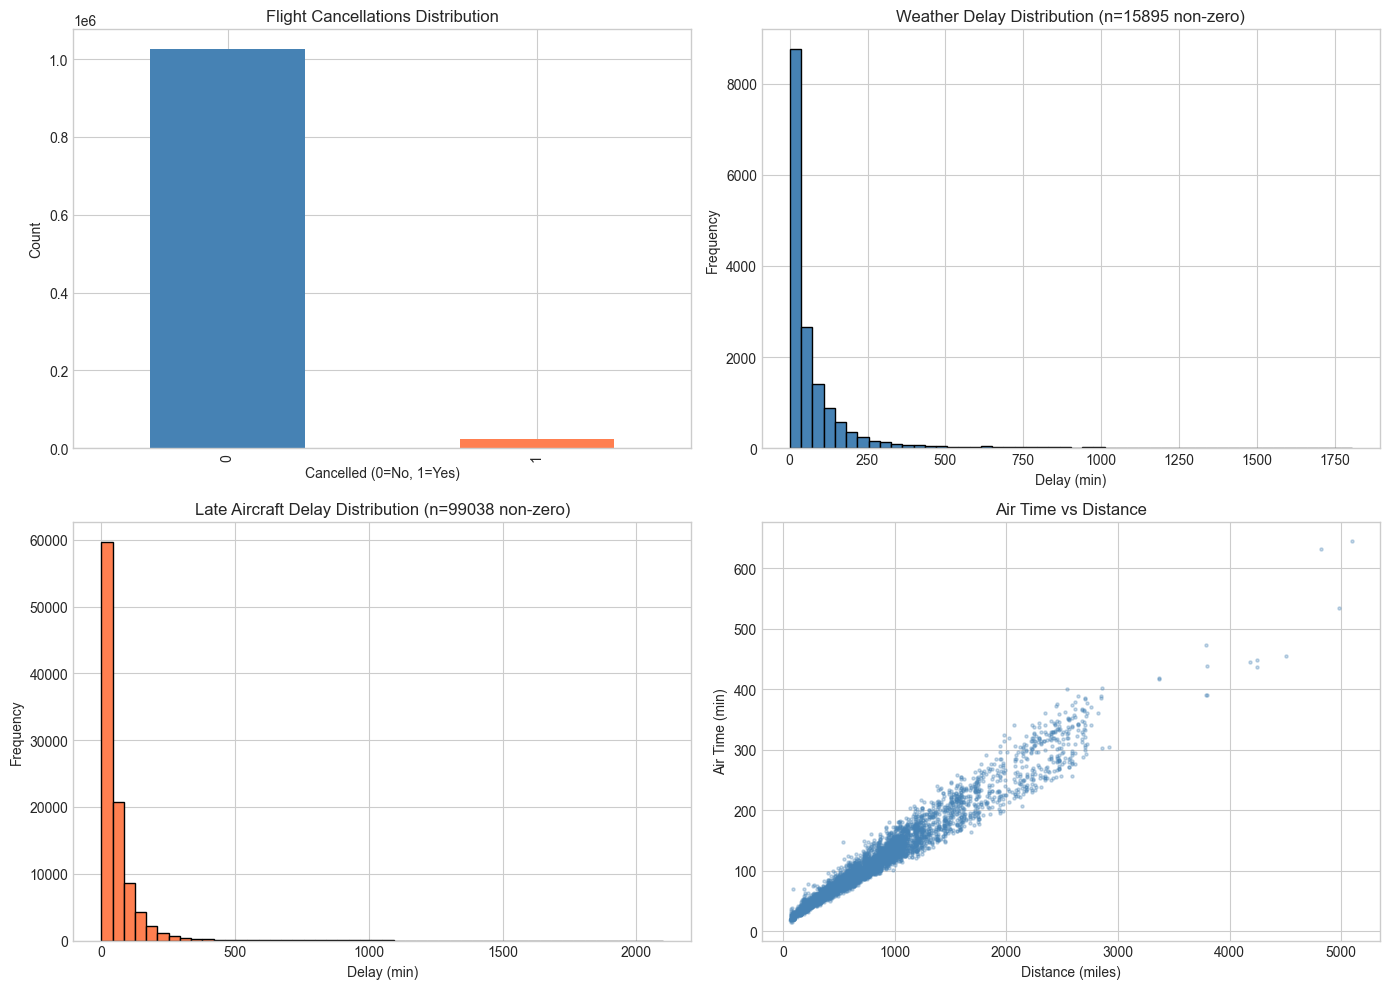

EDA plots saved.


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
df['cancelled'].value_counts().plot(kind='bar', ax=axes[0,0], color=['steelblue','coral'])
axes[0,0].set_title('Flight Cancellations Distribution')
axes[0,0].set_xlabel('Cancelled (0=No, 1=Yes)'); axes[0,0].set_ylabel('Count')
wd = df[df['weather_delay']>0]['weather_delay']
axes[0,1].hist(wd, bins=50, color='steelblue', edgecolor='black')
axes[0,1].set_title(f'Weather Delay Distribution (n={len(wd)} non-zero)')
axes[0,1].set_xlabel('Delay (min)'); axes[0,1].set_ylabel('Frequency')
ld = df[df['late_aircraft_delay']>0]['late_aircraft_delay']
axes[1,0].hist(ld, bins=50, color='coral', edgecolor='black')
axes[1,0].set_title(f'Late Aircraft Delay Distribution (n={len(ld)} non-zero)')
axes[1,0].set_xlabel('Delay (min)'); axes[1,0].set_ylabel('Frequency')
ss = df.sample(min(5000,len(df)), random_state=42)
axes[1,1].scatter(ss['distance'], ss['air_time'], alpha=0.3, s=5, color='steelblue')
axes[1,1].set_title('Air Time vs Distance')
axes[1,1].set_xlabel('Distance (miles)'); axes[1,1].set_ylabel('Air Time (min)')
plt.tight_layout()
plt.savefig('../outputs/eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA plots saved.')

## 2. Data Preprocessing

In [5]:
# Create working copies - separate for cancellation vs delay models
data_full = df.copy()

# Feature engineering on full dataset (for cancellation model)
data_full['dep_hour'] = data_full['dep_time'].fillna(0).astype(int) // 100
data_full['dep_hour'] = data_full['dep_hour'].clip(0, 23)
data_full['is_weekend'] = (data_full['day_of_week'].isin([6, 7])).astype(int)
def get_season(m):
    if m in [12,1,2]: return 'Winter'
    elif m in [3,4,5]: return 'Spring'
    elif m in [6,7,8]: return 'Summer'
    else: return 'Fall'
data_full['season'] = data_full['month'].apply(get_season)
le_origin = LabelEncoder()
data_full['origin_encoded'] = le_origin.fit_transform(data_full['origin'])
le_season = LabelEncoder()
data_full['season_encoded'] = le_season.fit_transform(data_full['season'])

# For delay/operational models, filter to non-cancelled flights with valid data
data = data_full[data_full['cancelled'] == 0].copy()
data = data.dropna(subset=['air_time', 'distance', 'dep_time'])
data['has_weather_delay'] = (data['weather_delay'] > 0).astype(int)
data['has_late_aircraft_delay'] = (data['late_aircraft_delay'] > 0).astype(int)

print(f'Full dataset shape: {data_full.shape}')
print(f'Non-cancelled dataset shape: {data.shape}')
print(f'Cancellation rate: {data_full["cancelled"].mean():.4%}')
print(f'Weather delay rate (non-cancelled): {data["has_weather_delay"].mean():.4%}')
print(f'Late aircraft delay rate (non-cancelled): {data["has_late_aircraft_delay"].mean():.4%}')

Full dataset shape: (1048575, 23)
Non-cancelled dataset shape: (1022824, 25)
Cancellation rate: 2.2226%
Weather delay rate (non-cancelled): 1.5540%
Late aircraft delay rate (non-cancelled): 9.6828%


## 3. Model 1 - Flight Cancellation Prediction (Logistic Regression)

In [6]:
feature_cols_cancel = ['month', 'day_of_week', 'dep_hour', 'is_weekend',
                       'origin_encoded', 'season_encoded', 'distance']
X_cancel = data_full[feature_cols_cancel].copy()
y_cancel = data_full['cancelled'].copy()

# Check class distribution
print(f'Cancellation class distribution:\n{y_cancel.value_counts()}')
n_classes = y_cancel.nunique()

if n_classes >= 2:
    X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
        X_cancel, y_cancel, test_size=0.2, random_state=42, stratify=y_cancel)
    scaler_c = StandardScaler()
    X_train_c_scaled = scaler_c.fit_transform(X_train_c)
    X_test_c_scaled = scaler_c.transform(X_test_c)
    log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
    log_reg.fit(X_train_c_scaled, y_train_c)
    y_pred_c = log_reg.predict(X_test_c_scaled)
    y_pred_proba_c = log_reg.predict_proba(X_test_c_scaled)[:, 1]
    print(f'\n=== Flight Cancellation - Logistic Regression ===')
    print(f'Accuracy: {accuracy_score(y_test_c, y_pred_c):.4f}')
    try:
        print(f'ROC-AUC: {roc_auc_score(y_test_c, y_pred_proba_c):.4f}')
    except:
        print('ROC-AUC: Could not compute')
    print(f'\n{classification_report(y_test_c, y_pred_c)}')
    coef_df = pd.DataFrame({'Feature': feature_cols_cancel,
        'Coefficient': log_reg.coef_[0]}).sort_values('Coefficient', key=abs, ascending=False)
    print(coef_df.to_string(index=False))
    cancel_model_ok = True
else:
    print('\nOnly one class present - no cancellations in dataset.')
    print('Skipping logistic regression (all flights completed).')
    cancel_model_ok = False

Cancellation class distribution:
cancelled
0    1025269
1      23306
Name: count, dtype: int64



=== Flight Cancellation - Logistic Regression ===
Accuracy: 0.9717
ROC-AUC: 0.9805

              precision    recall  f1-score   support

           0       1.00      0.97      0.99    205054
           1       0.44      0.97      0.60      4661

    accuracy                           0.97    209715
   macro avg       0.72      0.97      0.79    209715
weighted avg       0.99      0.97      0.98    209715

       Feature  Coefficient
      dep_hour    -3.188406
         month    -0.659343
   day_of_week    -0.192676
    is_weekend     0.119318
      distance    -0.084739
origin_encoded    -0.042176
season_encoded     0.000000


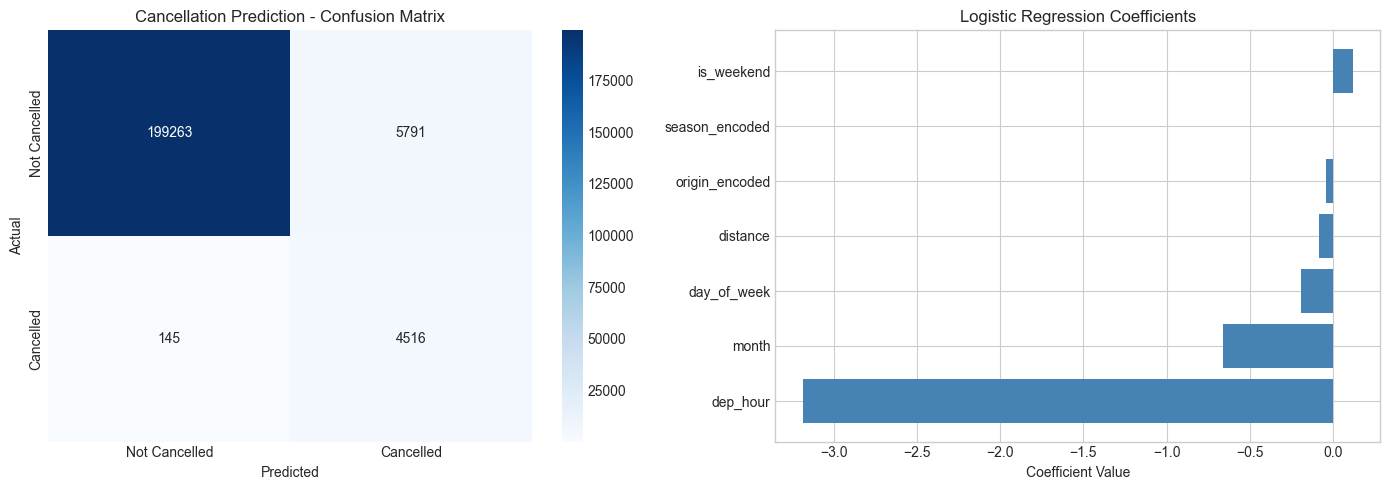

In [7]:
if cancel_model_ok:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    cm = confusion_matrix(y_test_c, y_pred_c)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Not Cancelled', 'Cancelled'],
                yticklabels=['Not Cancelled', 'Cancelled'])
    axes[0].set_title('Cancellation Prediction - Confusion Matrix')
    axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')
    coef_df_sorted = coef_df.sort_values('Coefficient')
    axes[1].barh(coef_df_sorted['Feature'], coef_df_sorted['Coefficient'], color='steelblue')
    axes[1].set_title('Logistic Regression Coefficients')
    axes[1].set_xlabel('Coefficient Value')
    plt.tight_layout()
    plt.savefig('../outputs/cancellation_model.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Cancellation model skipped - visualization not available.')

## 4. Model 2 - Weather Delay Regression

In [8]:
weather_data = data[data['weather_delay']>0].copy()
print(f'Flights with weather delays: {len(weather_data)}')
if len(weather_data) > 100:
    feature_cols_weather = ['month','day_of_week','dep_hour','is_weekend','origin_encoded','distance','taxi_out']
    X_weather = weather_data[feature_cols_weather]
    y_weather = weather_data['weather_delay']
    X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(X_weather, y_weather, test_size=0.2, random_state=42)
    scaler_w = StandardScaler()
    X_train_w_scaled = scaler_w.fit_transform(X_train_w)
    X_test_w_scaled = scaler_w.transform(X_test_w)
    lr_weather = LinearRegression()
    lr_weather.fit(X_train_w_scaled, y_train_w)
    y_pred_w = lr_weather.predict(X_test_w_scaled)
    print(f'\n=== Weather Delay - Linear Regression ===')
    print(f'R2 Score: {r2_score(y_test_w, y_pred_w):.4f}')
    print(f'MAE: {mean_absolute_error(y_test_w, y_pred_w):.2f} min')
    print(f'RMSE: {np.sqrt(mean_squared_error(y_test_w, y_pred_w)):.2f} min')
    weather_coef = pd.DataFrame({'Feature': feature_cols_weather, 'Coefficient': lr_weather.coef_}).sort_values('Coefficient', key=abs, ascending=False)
    print(f'\n{weather_coef.to_string(index=False)}')

Flights with weather delays: 15895

=== Weather Delay - Linear Regression ===
R2 Score: 0.0128
MAE: 77.89 min
RMSE: 144.32 min

       Feature  Coefficient
      dep_hour   -15.535772
      distance    -5.329181
   day_of_week    -4.949214
origin_encoded     4.103870
      taxi_out     3.295059
    is_weekend     2.715686
         month    -1.471229


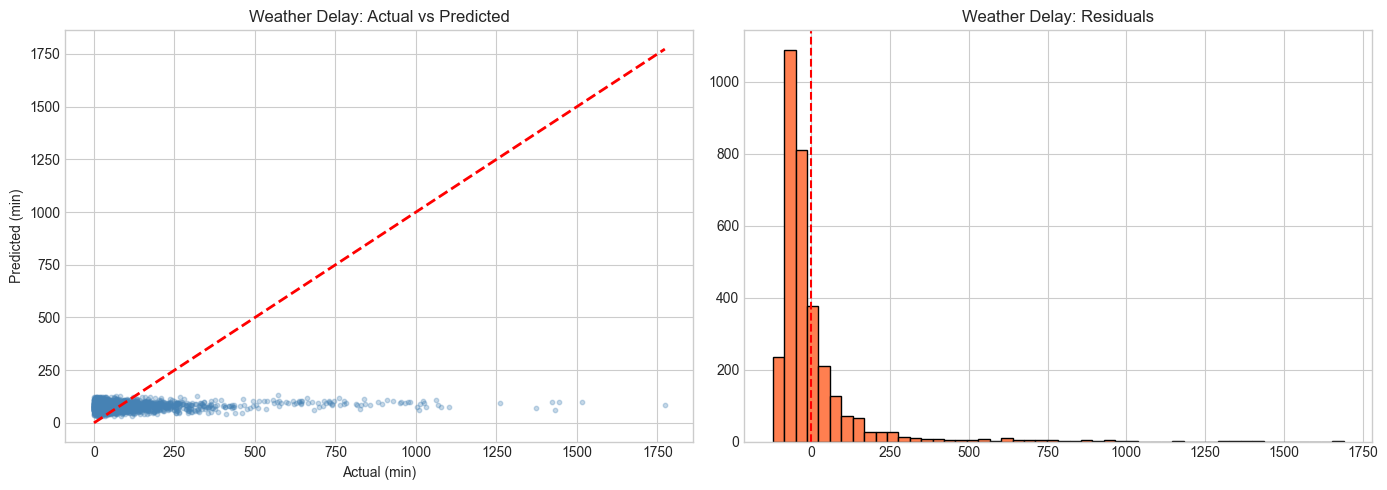

In [9]:
if len(weather_data) > 100:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].scatter(y_test_w, y_pred_w, alpha=0.3, s=10, color='steelblue')
    mx = max(y_test_w.max(), y_pred_w.max())
    axes[0].plot([0,mx],[0,mx],'r--',lw=2)
    axes[0].set_title('Weather Delay: Actual vs Predicted')
    axes[0].set_xlabel('Actual (min)'); axes[0].set_ylabel('Predicted (min)')
    res = y_test_w - y_pred_w
    axes[1].hist(res, bins=50, color='coral', edgecolor='black')
    axes[1].set_title('Weather Delay: Residuals')
    axes[1].axvline(x=0, color='red', linestyle='--')
    plt.tight_layout()
    plt.savefig('../outputs/weather_delay_model.png', dpi=150, bbox_inches='tight')
    plt.show()

## 5. Model 3 - Late Aircraft Delay Regression

In [10]:
late_data = data[data['late_aircraft_delay']>0].copy()
print(f'Flights with late aircraft delays: {len(late_data)}')
if len(late_data) > 100:
    feature_cols_late = ['month','day_of_week','dep_hour','is_weekend','origin_encoded','distance','taxi_out','taxi_in']
    X_late = late_data[feature_cols_late]
    y_late = late_data['late_aircraft_delay']
    X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(X_late, y_late, test_size=0.2, random_state=42)
    scaler_l = StandardScaler()
    X_train_l_scaled = scaler_l.fit_transform(X_train_l)
    X_test_l_scaled = scaler_l.transform(X_test_l)
    lr_late = LinearRegression()
    lr_late.fit(X_train_l_scaled, y_train_l)
    y_pred_l = lr_late.predict(X_test_l_scaled)
    print(f'\n=== Late Aircraft Delay - Linear Regression ===')
    print(f'R2 Score: {r2_score(y_test_l, y_pred_l):.4f}')
    print(f'MAE: {mean_absolute_error(y_test_l, y_pred_l):.2f} min')
    print(f'RMSE: {np.sqrt(mean_squared_error(y_test_l, y_pred_l)):.2f} min')
    late_coef = pd.DataFrame({'Feature': feature_cols_late, 'Coefficient': lr_late.coef_}).sort_values('Coefficient', key=abs, ascending=False)
    print(f'\n{late_coef.to_string(index=False)}')

Flights with late aircraft delays: 99038

=== Late Aircraft Delay - Linear Regression ===
R2 Score: 0.0047
MAE: 45.42 min
RMSE: 83.82 min

       Feature  Coefficient
   day_of_week    -3.673806
       taxi_in     3.273086
         month    -2.615604
    is_weekend     2.251338
      taxi_out     2.185527
      dep_hour     1.427021
origin_encoded     1.184653
      distance     0.947396


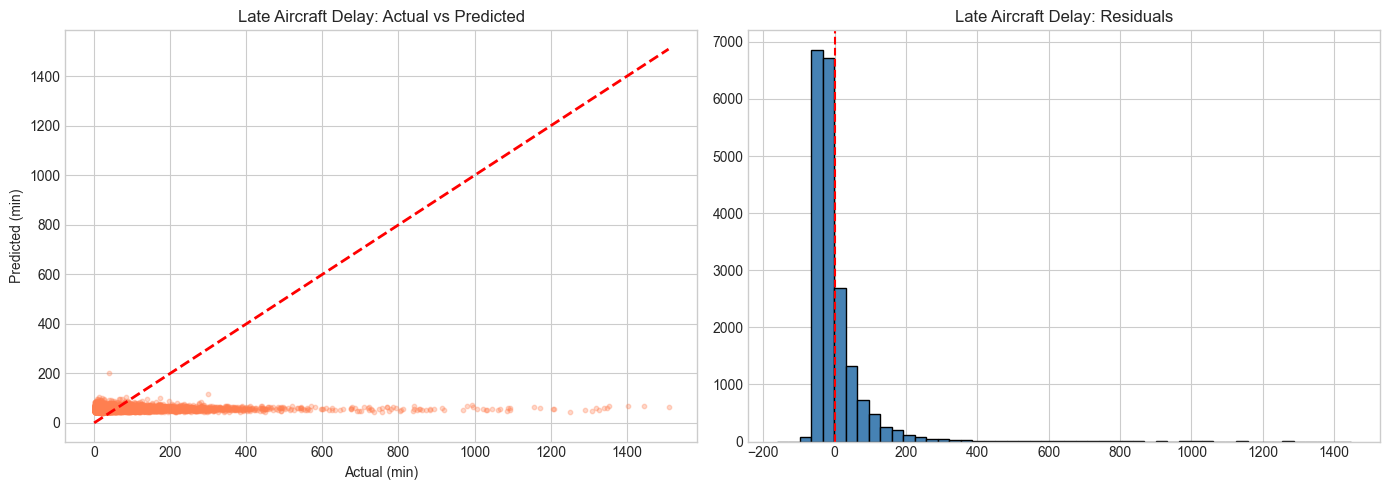

In [11]:
if len(late_data) > 100:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].scatter(y_test_l, y_pred_l, alpha=0.3, s=10, color='coral')
    mx = max(y_test_l.max(), y_pred_l.max())
    axes[0].plot([0,mx],[0,mx],'r--',lw=2)
    axes[0].set_title('Late Aircraft Delay: Actual vs Predicted')
    axes[0].set_xlabel('Actual (min)'); axes[0].set_ylabel('Predicted (min)')
    res_l = y_test_l - y_pred_l
    axes[1].hist(res_l, bins=50, color='steelblue', edgecolor='black')
    axes[1].set_title('Late Aircraft Delay: Residuals')
    axes[1].axvline(x=0, color='red', linestyle='--')
    plt.tight_layout()
    plt.savefig('../outputs/late_aircraft_delay_model.png', dpi=150, bbox_inches='tight')
    plt.show()

## 6. Operational Patterns Analysis

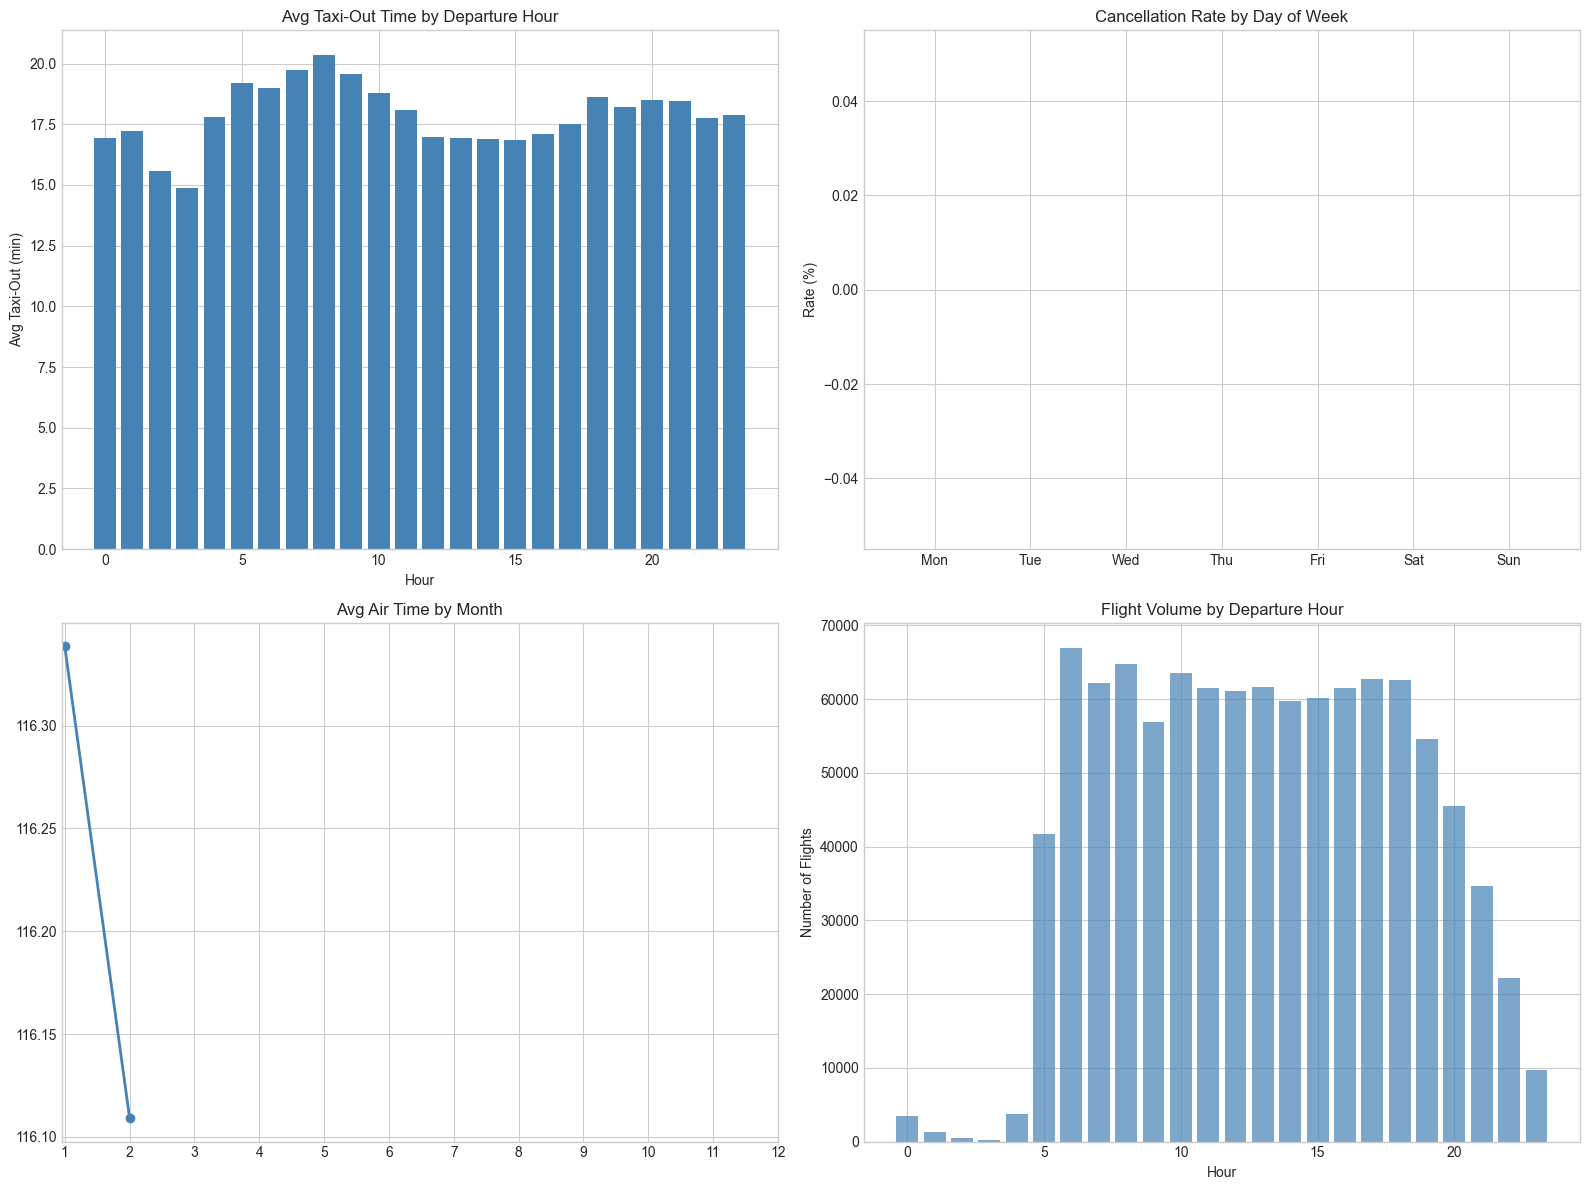

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
hourly_taxi = data.groupby('dep_hour')['taxi_out'].mean()
axes[0,0].bar(hourly_taxi.index, hourly_taxi.values, color='steelblue')
axes[0,0].set_title('Avg Taxi-Out Time by Departure Hour')
axes[0,0].set_xlabel('Hour'); axes[0,0].set_ylabel('Avg Taxi-Out (min)')
day_names = {1:'Mon',2:'Tue',3:'Wed',4:'Thu',5:'Fri',6:'Sat',7:'Sun'}
daily_cancel = data.groupby('day_of_week')['cancelled'].mean()*100
axes[0,1].bar([day_names.get(d,d) for d in daily_cancel.index], daily_cancel.values, color='coral')
axes[0,1].set_title('Cancellation Rate by Day of Week')
axes[0,1].set_ylabel('Rate (%)')
monthly_airtime = data.groupby('month')['air_time'].mean()
axes[1,0].plot(monthly_airtime.index, monthly_airtime.values, 'o-', color='steelblue', lw=2)
axes[1,0].set_title('Avg Air Time by Month'); axes[1,0].set_xticks(range(1,13))
hourly_flights = data.groupby('dep_hour').size()
axes[1,1].bar(hourly_flights.index, hourly_flights.values, color='steelblue', alpha=0.7)
axes[1,1].set_title('Flight Volume by Departure Hour')
axes[1,1].set_xlabel('Hour'); axes[1,1].set_ylabel('Number of Flights')
plt.tight_layout()
plt.savefig('../outputs/operational_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
feature_cols_ops = ['month','day_of_week','dep_hour','is_weekend','origin_encoded','distance']
ops_data = data.dropna(subset=['taxi_out'])
X_ops = ops_data[feature_cols_ops]
y_ops = ops_data['taxi_out']
X_train_o, X_test_o, y_train_o, y_test_o = train_test_split(X_ops, y_ops, test_size=0.2, random_state=42)
scaler_o = StandardScaler()
X_train_o_scaled = scaler_o.fit_transform(X_train_o)
X_test_o_scaled = scaler_o.transform(X_test_o)
lr_ops = LinearRegression()
lr_ops.fit(X_train_o_scaled, y_train_o)
y_pred_o = lr_ops.predict(X_test_o_scaled)
print('=== Taxi-Out Time - Linear Regression (Operational Patterns) ===')
print(f'R2 Score: {r2_score(y_test_o, y_pred_o):.4f}')
print(f'MAE: {mean_absolute_error(y_test_o, y_pred_o):.2f} min')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test_o, y_pred_o)):.2f} min')
ops_coef = pd.DataFrame({'Feature': feature_cols_ops, 'Coefficient': lr_ops.coef_}).sort_values('Coefficient', key=abs, ascending=False)
print(f'\n{ops_coef.to_string(index=False)}')

=== Taxi-Out Time - Linear Regression (Operational Patterns) ===
R2 Score: 0.0060
MAE: 6.72 min
RMSE: 10.35 min

       Feature  Coefficient
         month    -0.578984
      dep_hour    -0.529474
      distance     0.255809
origin_encoded    -0.192562
   day_of_week     0.016201
    is_weekend     0.010502


## 7. Model Summary

In [14]:
print('='*70)
print('MODEL PERFORMANCE SUMMARY')
print('='*70)
summary = []
if cancel_model_ok:
    summary.append({'Model':'Cancellation (Logistic)','Type':'Classification','Metric':'Accuracy','Value':f'{accuracy_score(y_test_c, y_pred_c):.4f}'})
else:
    summary.append({'Model':'Cancellation (Logistic)','Type':'Classification','Metric':'Accuracy','Value':'N/A (single class)'})
if len(weather_data) > 100:
    summary.append({'Model':'Weather Delay (Linear)','Type':'Regression','Metric':'R2','Value':f'{r2_score(y_test_w, y_pred_w):.4f}'})
if len(late_data) > 100:
    summary.append({'Model':'Late Aircraft Delay (Linear)','Type':'Regression','Metric':'R2','Value':f'{r2_score(y_test_l, y_pred_l):.4f}'})
summary.append({'Model':'Taxi-Out Time (Linear)','Type':'Regression','Metric':'R2','Value':f'{r2_score(y_test_o, y_pred_o):.4f}'})
print(pd.DataFrame(summary).to_string(index=False))
print('\nAll outputs saved to ../outputs/')

MODEL PERFORMANCE SUMMARY
                       Model           Type   Metric  Value
     Cancellation (Logistic) Classification Accuracy 0.9717
      Weather Delay (Linear)     Regression       R2 0.0128
Late Aircraft Delay (Linear)     Regression       R2 0.0047
      Taxi-Out Time (Linear)     Regression       R2 0.0060

All outputs saved to ../outputs/
